<a href="https://colab.research.google.com/github/sarahmdias19/AI-ML-For-Fluids/blob/main/Lesson_1_2_pureTensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A cohort for IA and Fluid Mechanics


# STEP 0. Python Environment Setup (Windows)
!! Virtual Environment
A Python virtual environment has to be created to isolate project dependencies:

1. Install Python 3.12 for Windows.
    https://www.python.org/downloads/release/python-31213/
2. REBOOT your computer

Using Power shell, go to your work directory for this project.
- Create the enviroment in powershell (change the second venv to anything easy to remember):
```bash
python -m venv venv
```
- Environment activation:
```bash
.\venv\Scripts\Activate.ps1
```
- Sometimes it is necessary to change the PowerShell execution policy was updated (user scope only):
```bash
Set-ExecutionPolicy -Scope CurrentUser -ExecutionPolicy RemoteSigned
```
## Jupyter / VS Code Kernel
The virtual environment was registered as a Jupyter kernel:
```bash
python -m ipykernel install --user --name venv --display-name "Python (venv)"
```
## Install Packages
The following packages need to be installed inside the virtual environment:
```bash
pip install numpy
pip install matplotlib
pip install tensorflow
```


```python
# =========================================================
# Goal:
# Learn the function:
#
#       y = 3x + 2
# using tensorFlow
# We manually define:
#   - the weight w
#   - the bias b
#   - the prediction
#   - the loss
#   - the training loop
# =========================================================

# ---------------------------------------------------------
# 1. Create training data
# ---------------------------------------------------------

In [1]:
# =========================================================
# Import libraries
# =========================================================

# NumPy is a library for numerical computations.
# We use it to create arrays of numbers and to perform operations
# on many numbers at the same time.
import numpy as np

# TensorFlow is the machine learning library.
# In this example, we use TensorFlow to:
#   - create trainable variables,
#   - compute derivatives automatically,
#   - update the model parameters.
import tensorflow as tf

# Matplotlib is a plotting library.
# We use it to draw the loss curve and the learned function.
import matplotlib.pyplot as plt


```python
# In Python, we can import a library using a shorter name.
#
# For example:
#
#       import numpy as np
#
# means:
#
#       "Import the NumPy library, but call it np in this code."
#
# This is useful because we will use NumPy many times.
# Instead of writing:
#
#       numpy.array(...)
#
# we can write:
#
#       np.array(...)
#
# The shorter name is called an alias.

In [20]:
# ---------------------------------------------------------
# 1. Training data using NumPy
# ---------------------------------------------------------

# We create the input data for training.
#
# np.array(...) creates a NumPy array.
# A NumPy array is similar to a Python list, but it is designed
# for numerical computations.
#
# The values inside the array are the input values x.
# In this example, x goes from -5 to 5.
#
# dtype=np.float32 means that the numbers will be stored as
# 32-bit floating-point numbers.
#
# We use floats because neural networks usually work with
# decimal numbers, not integers.
x_train = np.array(
    [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
    dtype=np.float32
)


# We create the correct output values.
#
# The function we want the model to learn is:
#
#       y = 3x + 2
#
# Since x_train is a NumPy array, Python applies the operation
# to all values at once.
#
# This means that NumPy automatically computes:
#
#       y = 3*(-5) + 2
#       y = 3*(-4) + 2
#       y = 3*(-3) + 2
#       ...
#       y = 3*(5) + 2
#
# So y_train will contain the correct answer for every x value.
y_train = 3 * x_train + 2

In [21]:
# ---------------------------------------------------------
# 2. Create the parameters of one neuron
# ---------------------------------------------------------

# A single neuron computes:
#
#       y_pred = w * x + b
#
# where:
#   w is the weight,
#   b is the bias,
#   x is the input,
#   y_pred is the prediction.
#
# Our goal is that the neuron learns:
#
#       w ≈ 3
#       b ≈ 2
#
# because the real function is:
#
#       y = 3x + 2


# tf.Variable creates a TensorFlow variable.
#
# A TensorFlow variable is a number that TensorFlow can change during training.
#
# Here, w starts at 0.0.
# This is not correct yet. The correct value should become close to 3.
w = tf.Variable(10.0)

# Here, b also starts at 0.0.
# This is not correct yet. The correct value should become close to 2.
b = tf.Variable(-5.0)

# .numpy() converts the TensorFlow variable into a normal Python/NumPy value
# so we can print it easily.
print("Initial w:", w.numpy())
print("Initial b:", b.numpy())


Initial w: 10.0
Initial b: -5.0


In [22]:
# ---------------------------------------------------------
# 3. Define the optimizer
# ---------------------------------------------------------

# The optimizer is the algorithm that updates w and b.
#
# SGD means Stochastic Gradient Descent.
#
# Gradient descent updates the parameters in the direction that reduces
# the loss function.
#
# learning_rate controls how big each update is:
#
#   - If learning_rate is too small, training is very slow.
#   - If learning_rate is too large, training may become unstable.
optimizer = tf.optimizers.RMSprop(learning_rate=0.01)


## Note about optimizers

In this first example, we use **SGD**:

```python
optimizer = tf.optimizers.SGD(learning_rate=0.01)
```

SGD means **Stochastic Gradient Descent**. It is one of the simplest optimization algorithms. The idea is very intuitive: compute the gradient of the loss function and update the model parameters in the opposite direction of the gradient.

During the course, we will see several optimizers. Some of the most common are:

- **SGD**: simple and useful for understanding the basic idea of gradient descent.
- **SGD with momentum**: improves SGD by adding a kind of “memory” of previous updates.
- **RMSprop**: adapts the learning rate for each parameter and is often useful for unstable gradients.
- **Adam**: one of the most widely used optimizers in deep learning. It combines ideas from momentum and adaptive learning rates.
- **AdamW**: a variant of Adam that handles weight decay in a better way and is often used in modern deep learning models.

For now, we only need to understand that the optimizer is the part of the algorithm that updates the parameters of the model.

In this simple example, the parameters are only $w$ and $b$:

Later, in larger neural networks, the optimizer will update thousands, millions, or even billions of parameters.

In [23]:
# ---------------------------------------------------------
# 4. Training loop
# ---------------------------------------------------------

# We create an empty list to store the loss value at each epoch.
# Later, we will plot this list to see whether the model is learning.
loss_history = []


# This loop repeats the training process 500 times.
#
# One epoch means one full training step over the training data.
#
# In this small example, all the data are used at once in each epoch.
# In larger examples, the data is usually divided into batches.
# Question: is the next line totally correct?
for epoch in range(500):

    # -----------------------------------------------------
    # Automatic differentiation with GradientTape
    # -----------------------------------------------------

    # TensorFlow needs to know which operations are used to compute the loss.
    #
    # tf.GradientTape() records the mathematical operations inside this block.
    #
    # Later, TensorFlow uses this record to compute derivatives automatically.
    #
    # This is called automatic differentiation.
    with tf.GradientTape() as tape:

        # -------------------------------------------------
        # Model prediction
        # -------------------------------------------------

        # The neuron predicts y using the current values of w and b.
        #
        # Since x_train is an array, this operation is applied to all x values.
        #
        # If w and b are still wrong, the predictions will be wrong.
        y_pred = w * x_train + b

        # -------------------------------------------------
        # Loss function
        # -------------------------------------------------

        # The loss measures how wrong the predictions are.
        #
        # We use the mean squared error:
        #
        #       loss = mean((y_true - y_pred)^2)
        #
        # Step by step:
        #
        #   y_train - y_pred
        #       computes the error for every training point.
        #
        #   (y_train - y_pred) ** 2
        #       squares the errors.
        #
        #   tf.reduce_mean(...)
        #       computes the average value.
        #
        # If the loss is large, the model is bad.
        # If the loss is close to zero, the model is good.
        loss = tf.reduce_mean((y_train - y_pred) ** 2)

    # -----------------------------------------------------
    # Compute gradients
    # -----------------------------------------------------

    # Here TensorFlow computes the derivatives of the loss
    # with respect to w and b.
    #
    # In mathematical notation, it computes:
    #
    #       d(loss)/dw
    #       d(loss)/db
    #
    # These derivatives tell us how w and b should change
    # to reduce the loss.
    gradients = tape.gradient(loss, [w, b])

    # -----------------------------------------------------
    # Update w and b
    # -----------------------------------------------------

    # The optimizer uses the gradients to update the variables.
    #
    # This is the TensorFlow version of doing something like:
    #
    #       w = w - learning_rate * dw
    #       b = b - learning_rate * db
    #
    # zip(gradients, [w, b]) pairs each gradient with its variable:
    #
    #       gradient for w  ->  w
    #       gradient for b  ->  b
    optimizer.apply_gradients(zip(gradients, [w, b]))

    # -----------------------------------------------------
    # Save the loss value
    # -----------------------------------------------------

    # We store the current loss in the list loss_history.
    #
    # Again, .numpy() converts the TensorFlow value into a regular number.
    loss_history.append(loss.numpy())

    # -----------------------------------------------------
    # Print progress every 50 epochs
    # -----------------------------------------------------

    # epoch % 50 == 0 means:
    #
    #       print only when epoch is divisible by 50
    #
    # So it prints at:
    #
    #       0, 50, 100, 150, ...
    if epoch % 50 == 0:

        # This prints:
        #   - the epoch number,
        #   - the current loss,
        #   - the current value of w,
        #   - the current value of b.
        #
        # The formatting:
        #   :.6f means 6 decimal digits,
        #   :.4f means 4 decimal digits.
        print(
            f"Epoch {epoch:3d} | "
            f"loss = {loss.numpy():.6f} | "
            f"w = {w.numpy():.4f} | "
            f"b = {b.numpy():.4f}"
        )


Epoch   0 | loss = 539.000000 | w = 9.9684 | b = -4.9684
Epoch  50 | loss = 452.597473 | w = 9.4046 | b = -4.4046
Epoch 100 | loss = 385.685852 | w = 8.9115 | b = -3.9115
Epoch 150 | loss = 324.225861 | w = 8.4193 | b = -3.4193
Epoch 200 | loss = 268.175171 | w = 7.9277 | b = -2.9277
Epoch 250 | loss = 217.523926 | w = 7.4371 | b = -2.4371
Epoch 300 | loss = 172.261337 | w = 6.9475 | b = -1.9475
Epoch 350 | loss = 132.373779 | w = 6.4593 | b = -1.4593
Epoch 400 | loss = 97.843353 | w = 5.9727 | b = -0.9727
Epoch 450 | loss = 68.646881 | w = 5.4885 | b = -0.4885


## Expected idea

The model starts with wrong parameters.

At the beginning, the loss may be large.

However, gradient descent updates `w` and `b` step by step.

After enough training, the model should move toward:

```text
w ≈ 3
b ≈ 2
```

---


A very small learning rate makes training slow.

A good learning rate reduces the loss smoothly.

A very large learning rate can make training unstable.

The model may even fail to learn if the updates are too large.


In [ ]:
# ---------------------------------------------------------
# 5. Final result
# ---------------------------------------------------------

# After training, we print the values learned by the model.
#
# If training worked correctly:
#
#       w should be close to 3
#       b should be close to 2
print("\nLearned parameters:")
print("w =", w.numpy())
print("b =", b.numpy())

# These are the correct values from the original function:
#
#       y = 3x + 2
print("\nExpected:")
print("w = 3")
print("b = 2")



Learned parameters:
w = 2.9999995
b = 1.999918

Expected:
w = 3
b = 2


In [ ]:
# ---------------------------------------------------------
# 6. Test the model
# ---------------------------------------------------------

# Now we test the trained model with a new value.
#
# This value was not explicitly used as a single test example.
x_new = 10.0

# The model predicts y using the learned values of w and b.
y_new = w * x_new + b

# We print the model prediction.
print("\nPrediction for x = 10:")
print("Model prediction:", y_new.numpy())

# We also print the correct answer.
#
# Since the true function is:
#
#       y = 3x + 2
#
# for x = 10:
#
#       y = 3*10 + 2 = 32
print("Correct answer:", 3 * x_new + 2)


Prediction for x = 10:
Model prediction: 31.999914
Correct answer: 32.0


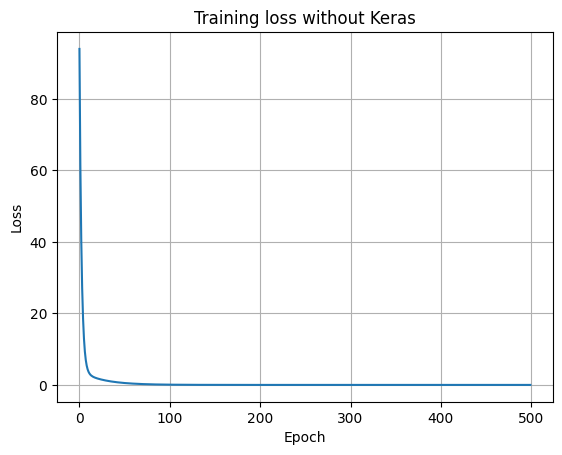

In [ ]:
# ---------------------------------------------------------
# 7. Plot the loss
# ---------------------------------------------------------

# We create a new figure.
plt.figure()

# We plot the loss values stored during training.
#
# The horizontal axis is the epoch number.
# The vertical axis is the loss.
plt.plot(loss_history)

# Label for the horizontal axis.
plt.xlabel("Epoch")

# Label for the vertical axis.
plt.ylabel("Loss")

# Title of the plot.
plt.title("Training loss")

# Add a grid to make the plot easier to read.
plt.grid(True)

# Show the plot.
plt.show()


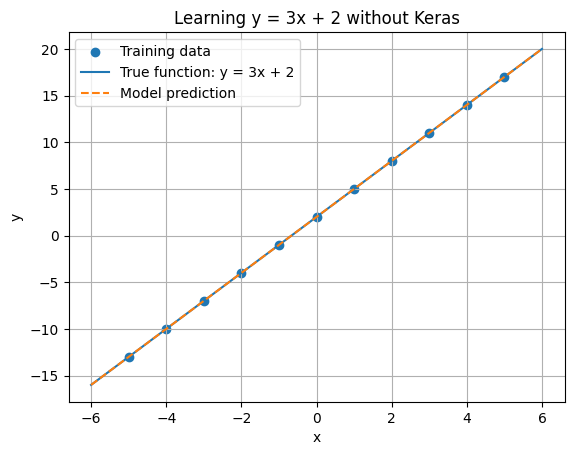

In [ ]:
# ---------------------------------------------------------
# 8. Plot the learned function
# ---------------------------------------------------------

# We create many x values between -6 and 6.
#
# np.linspace(-6, 6, 100) creates 100 equally spaced values
# between -6 and 6.
#
# astype(np.float32) converts them to 32-bit floating-point numbers.
x_plot = np.linspace(-6, 6, 100).astype(np.float32)

# These are the true y values from the real function:
#
#       y = 3x + 2
y_true = 3 * x_plot + 2

# These are the y values predicted by the trained model.
#
# We use w.numpy() and b.numpy() to convert TensorFlow variables
# into normal numerical values.
y_pred = w.numpy() * x_plot + b.numpy()

# Create a new figure.
plt.figure()

# Draw the original training points.
#
# scatter means that the points are shown individually.
plt.scatter(x_train, y_train, label="Training data")

# Draw the true function as a continuous line.
plt.plot(x_plot, y_true, label="True function: y = 3x + 2")

# Draw the function learned by the model.
#
# "--" means dashed line.
plt.plot(x_plot, y_pred, "--", label="Model prediction")

# Label for the horizontal axis.
plt.xlabel("x")

# Label for the vertical axis.
plt.ylabel("y")

# Show the legend.
# The legend explains what each line or set of points represents.
plt.legend()

# Add a grid.
plt.grid(True)

# Add a title.
plt.title("Learning y = 3x + 2 without Keras")

# Show the plot.
plt.show()



Some of the most common optimisers are:

## SGD

**Stochastic Gradient Descent** is one of the simplest optimization algorithms.

It updates the parameters in the opposite direction of the gradient.

In simple words:

```text
If the loss increases in one direction, move in the opposite direction.
```

---

## SGD with Momentum

SGD with momentum improves basic SGD.

It keeps some memory from previous updates.

This can help the optimizer move faster and avoid unstable oscillations.

---

## RMSprop

RMSprop adapts the learning rate for each parameter.

It is often useful when the gradients are unstable or have very different scales.

---

## Adam

Adam is one of the most widely used optimizers in deep learning.

It combines ideas from:

- momentum,
- adaptive learning rates.

Adam often works well without requiring too much manual tuning.

For this reason, Adam is usually a very good first choice.

---

## AdamW

AdamW is a modern variant of Adam.

It handles weight decay in a better way.

It is often used in modern deep learning models.

---

# Summary

| Exercise | What we change | Main idea |
|---|---|---|
| Exercise 1 | Initial values of `w` and `b` | Training can start from wrong parameters |
| Exercise 2 | Learning rate | The learning rate controls the size of the updates |
| Exercise 3 | Optimizer | Different optimizers update parameters differently |

---

# Final Discussion

In this example, the model has only two trainable parameters:

```text
w and b
```

In larger neural networks, the model may have thousands, millions, or even billions of parameters.

The optimizer is responsible for updating all of them.

In this simple example, we can clearly see what is happening:

1. The model predicts.
2. The loss is computed.
3. TensorFlow computes the gradients.
4. The optimizer updates the parameters.
5. The process is repeated many times.

This is the basic idea behind training neural networks.